In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('train.csv')
data.head()
raw_model_df = data.copy()


In [2]:

data['issueDate_clean'] = pd.to_datetime(data['issueDate']) # 把原来字符串形式的日期，转换成pandas能识别的真正日期格式

data['issueYear'] = data['issueDate_clean'].dt.year # 提取年份和月份
data['issueMonth'] = data['issueDate_clean'].dt.month
data[['issueYear','issueMonth','issueDate']].head(10)

data['earliesCreditLine_clean'] = pd.to_datetime(data['earliesCreditLine'], format = '%b-%Y')

data['earliesYear'] = data['earliesCreditLine_clean'].dt.year
data['earliesMonth'] = data['earliesCreditLine_clean'].dt.month
data[['earliesYear','earliesMonth','earliesCreditLine']].head(10)

# 构建信用历史长度'credit_history_years'

raw_model_df['credit_history_years'] = data['issueYear'] - data['earliesYear']

In [3]:
raw_model_df['dti_cleaned'] = data['dti'].copy()
raw_model_df.loc[raw_model_df['dti_cleaned'] < 0,['dti_cleaned']] = np.nan
raw_model_df.loc[raw_model_df['dti_cleaned'] == 999, ['dti_cleaned']] = np.nan
raw_model_df = raw_model_df.drop(columns = 'dti', errors = 'ignore')

In [4]:
def clean_employmentLength(x):
    if pd.isna(x):
        return np.nan
    elif x == '10+ years':
        return 10
    elif x == '< 1 year':
        return 0
    else:
        return int(str(x).replace('years','').replace('year',''))
    
raw_model_df['employmentLength_clean'] = raw_model_df['employmentLength'].apply(clean_employmentLength)
raw_model_df = raw_model_df.drop(columns = 'employmentLength', errors = 'ignore')

In [5]:
drop_cols = ['id','issueDate','earliesCreditLine',
             'ficoRangeHigh',
             'initialListStatus',
            'policyCode',
            'title',
            'employmentTitle',
            'grade']
raw_model_df = raw_model_df.drop(columns = drop_cols, errors = 'ignore')

In [6]:
type(raw_model_df['subGrade'])

pandas.core.series.Series

In [7]:
subgrade_order = {}
letters = ['A','B','C','D','E','F','G']
idx = 1
for letter in letters:
    for num in range(1,6):
        subgrade_order[f'{letter}{num}'] = idx
        idx += 1
raw_model_df['subGrade_coded'] = raw_model_df['subGrade'].map(subgrade_order)
raw_model_df = raw_model_df.drop(columns = 'subGrade', errors = 'ignore')

In [8]:
def ratio_calculatior(num, den):
    return np.where((den.isna()) | (den == 0), np.nan, num/den)

raw_model_df['installment_income_ratio'] = ratio_calculatior(data['installment'],data['annualIncome'])
raw_model_df['loan_income_ratio'] = ratio_calculatior(data['loanAmnt'],data['annualIncome'])

In [9]:
x = raw_model_df.drop(columns = 'isDefault')
y = raw_model_df['isDefault']

type(y)

pandas.core.series.Series

In [10]:
from sklearn.model_selection import train_test_split

x_temp, x_test, y_temp, y_test = train_test_split(x, y,
                                                   test_size = 0.1,
                                                 stratify = y,
                                                 random_state = 42)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp,
                                                     test_size = 2/9,
                                                     stratify = y_temp,
                                                     random_state = 42)

In [11]:
# 检查划分结果
print('x_train:',x_train.shape)
print('x_valid:',x_valid.shape)
print('x_test:',x_test.shape)
print("train:", y_train.mean())
print("valid:", y_valid.mean())
print("test :", y_test.mean())

x_train: (560000, 40)
x_valid: (160000, 40)
x_test: (80000, 40)
train: 0.1995125
valid: 0.1995125
test : 0.1995125


In [12]:
# 手动划分变量类型：


ordinal_categorical_features = ['term', 'subGrade_coded', 'employmentLength_clean']

nominal_categorical_features = ['homeOwnership', 'verificationStatus', 'purpose',
                               'regionCode', 'applicationType', 
                               'postCode']

discrete_numerical_features = ['delinquency_2years','pubRec','pubRecBankruptcies']

serial_numerical_features = ['loanAmnt','interestRate','installment','annualIncome',
                            'dti_cleaned','ficoRangeLow','openAcc','revolBal','revolUtil','totalAcc',
                            'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 
                             'n11', 'n12', 'n13', 'n14',
                            'credit_history_years','installment_income_ratio',
                            'loan_income_ratio']

len(ordinal_categorical_features+nominal_categorical_features+discrete_numerical_features+serial_numerical_features)

40

In [13]:
# 定义不同的preprocessor组

# 低基数无序分类变量(独热编码)
low_card_cat_features = ['homeOwnership', 'verificationStatus','applicationType']

# 高基数无序分类变量(独热编码)
high_card_cat_simple_features = ['purpose']

# 高基数无序分类变量(先合并低频类别，再独热编码)
high_card_cat_rare_features = ['regionCode','postCode']

# 连续型数值变量（对数变换）
log_serial_num_features = ['annualIncome', 'installment']

# 连续型数值变量（99分位数截尾）
winsor_serial_num_features = ['loanAmnt', 'interestRate', 'dti_cleaned', 'revolUtil']

remaining_num_features = [i for i in discrete_numerical_features+serial_numerical_features if i not in 
                          log_serial_num_features+winsor_serial_num_features]+ordinal_categorical_features

In [47]:
# 构建合并低频变量处理器：

from sklearn.base import BaseEstimator, TransformerMixin

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__ (self, min_freq = 0.01, other_label = 'Other'):
        self.min_freq = min_freq
        self.other_label = other_label
        self.frequent_categories_ = {}
        
    def fit(self, x, y = None):
        x = pd.DataFrame(x).copy()
        for col in x.columns:
            freq = x[col].value_counts(normalize = True, dropna = True) # 统计出现频率，而非数值
            self.frequent_categories_[col] = set(freq[freq > self.min_freq].index)
        return self
    
    def transform(self, x):
        x = pd.DataFrame(x).copy()
        for col in x.columns:
            
            x[col] = x[col].where(x[col].isin(self.frequent_categories_.get(col,set())), self.other_label)
        return x 
    
    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features, dtype=object)

        if hasattr(self, "feature_names_in_"):
            return np.array(self.feature_names_in_, dtype=object)

        if hasattr(self, "feature_names_in"):
            return np.array(self.feature_names_in, dtype=object)

        return None

# 将转化后的列都变为字符串
from sklearn.preprocessing import FunctionTransformer
def to_string_func(x):
    return pd.DataFrame(x).astype(str)


to_string_transformer = FunctionTransformer(to_string_func,
                                           feature_names_out = 'one-to-one')

In [48]:
# 构建99分位数截尾器：

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile = 0.00, upper_quantile = 0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.lower_bounds_ = None 
        self.upper_bounds_ = None
    
    def fit(self, x, y = None):
        x = pd.DataFrame(x).copy()
        self.lower_bounds_ = x.quantile(self.lower_quantile)
        self.upper_bounds_ = x.quantile(self.upper_quantile)
        return self
    def transform(self, x):
        x = pd.DataFrame(x).copy()
        x = x.clip(lower = self.lower_bounds_,
                  upper = self.upper_bounds_,
                  axis = 1)
        return x
    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features, dtype=object)

        if hasattr(self, "feature_names_in_"):
            return np.array(self.feature_names_in_, dtype=object)

        if hasattr(self, "feature_names_in"):
            return np.array(self.feature_names_in, dtype=object)

        return None

In [16]:
# 构建对数转换处理器：

from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log1p, feature_names_out = 'one-to-one')

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 低基数无序分类变量(独热编码)
low_card_cat_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')), #缺失值填充（都在这里做，每一组都要）
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# 高基数无序分类变量(独热编码)
high_card_cat_simple_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# 高基数无序分类变量(先合并低频类别，再独热编码)
high_card_cat_rare_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('rare_grouper', RareCategoryGrouper(min_freq = 0.01)),
    ('to_string',to_string_transformer),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# 连续型数值变量（对数变换）
log_serial_num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('log', log_transformer)
])

# 连续型数值变量（99分位数截尾）
winsor_serial_num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('winsor', Winsorizer(upper_quantile=0.99))
])

# 普通数值型+分类变量，只用填充缺失值
normal_num_transformer = Pipeline(steps= [
    ('imputer', SimpleImputer(strategy='median'))
])


In [18]:
# 构建数据预处理器

preprocessor = ColumnTransformer(
    transformers = [
        ('normal_num_transformer', normal_num_transformer, remaining_num_features),
        ('low_card_cat_transformer', low_card_cat_transformer, low_card_cat_features),
        ('high_card_cat_simple_transformer', high_card_cat_simple_transformer, high_card_cat_simple_features),
        ('high_card_cat_rare_transformer', high_card_cat_rare_transformer, high_card_cat_rare_features),
        ('log_serial_num_transformer', log_serial_num_transformer, log_serial_num_features),
        ('winsor_serial_num_transformer', winsor_serial_num_transformer, winsor_serial_num_features)
    ],
    remainder = 'drop')

In [19]:
from sklearn.linear_model import LogisticRegression

logit_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter = 1000,
                                     class_weight = 'balanced',
                                     random_state = 42))
])

In [20]:
# 训练模型
logit_pipeline.fit(x_train, y_train)

/Users/zhengleer/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('normal_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['delinquency_2years',
                                                   'pubRec',
                                                   'pubRecBankruptcies',
                                                   'ficoRangeLow', 'openAcc',
                                                   'revolBal', 'totalAcc', 'n0',
                                                   'n1', 'n2', 'n3', 'n4', 'n5',
                                                   'n6', 'n7', 'n8', 'n9',
                                                   'n10', 'n11', 'n12', 'n13',
                                                   'n14',
                                                   'credit_history_ye...
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>))]),
                                                  ['annualIncome',
                                                   'installment']),
                                                 ('winsor_serial_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsor',
                                                                   Winsorizer())]),
                                                  ['loanAmnt', 'interestRate',
                                                   'dti_cleaned',
                                                   'revolUtil'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators = 200,
                                         max_depth = 200,
                                         min_samples_split = 50,
                                         min_samples_leaf = 20,
                                         class_weight = 'balanced_subsample',
                                         random_state = 42,
                                         n_jobs = -1))
])

rf_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('normal_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['delinquency_2years',
                                                   'pubRec',
                                                   'pubRecBankruptcies',
                                                   'ficoRangeLow', 'openAcc',
                                                   'revolBal', 'totalAcc', 'n0',
                                                   'n1', 'n2', 'n3', 'n4', 'n5',
                                                   'n6', 'n7', 'n8', 'n9',
                                                   'n10', 'n11', 'n12', 'n13',
                                                   'n14',
                                                   'credit_history_ye...
                                                 ('winsor_serial_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsor',
                                                                   Winsorizer())]),
                                                  ['loanAmnt', 'interestRate',
                                                   'dti_cleaned',
                                                   'revolUtil'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=200, min_samples_leaf=20,
                                        min_samples_split=50, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
# 1. 定义基础模型
xgb_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42))
])



# 2. 定义参数空间
params = {
    'classifier__n_estimators': [100, 200, 300], # 树的数量，可理解为 boosting 迭代次数
    'classifier__max_depth': [3, 4, 5, 6], # 每棵树的最大深度
    'classifier__learning_rate': [0.03, 0.05, 0.1], # 学习率，控制每棵树对最终结果的贡献大小
    'classifier__min_child_weight': [1, 3, 5], # 子节点最小样本权重和
    'classifier__subsample': [0.8, 0.9, 1.0], # 每棵树训练时随机抽取的样本比例
    'classifier__colsample_bytree': [0.8, 0.9, 1.0], # 每棵树训练时随机抽取的特征比例
    'classifier__scale_pos_weight': [3, 4, 5]    # 给正类更高权重，用于缓解类别不平衡
}

# 3. 定义分层K折交叉验证
skf = StratifiedKFold(n_splits=3,  # 将训练数据分成3折，每次用其中1折做验证，其余4折做训练
                      shuffle=True, # 在分折之前先将样本随机打乱，避免原始数据顺序带来偏差
                      random_state=42)

# 4. 随机搜索
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=params,
    n_iter=4,               
    scoring='roc_auc',
    cv=skf,
    verbose=2, # 输出较详细的训练过程信息，便于观察搜索进度
    random_state=42,
    n_jobs=1
)

# 5. 开始训练
random_search.fit(x_train, y_train)

# 6. 输出最优参数和最优AUC
print("Best Params:", random_search.best_params_)
print("Best CV AUC:", random_search.best_score_)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=3, classifier__n_estimators=300, classifier__scale_pos_weight=4, classifier__subsample=1.0; total time=   7.3s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=3, classifier__n_estimators=300, classifier__scale_pos_weight=4, classifier__subsample=1.0; total time=   7.0s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=3, classifier__n_estimators=300, classifier__scale_pos_weight=4, classifier__subsample=1.0; total time=   6.9s
[CV] END classifier__colsample_bytree=0.9, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=5, classifier__n_estimators=300, classifier__scale_pos_weight=5, classifier__subsample=0.9; to

In [50]:
best_xgb = random_search.best_estimator_

In [51]:
y_valid_prob = logit_pipeline.predict_proba(x_valid)[:, 1]
rf_y_valid_prob = rf_pipeline.predict_proba(x_valid)[:, 1]
best_xgb_valid_prob = best_xgb.predict_proba(x_valid)[:, 1]

In [27]:
# 对三个模型分别检验ks值、Lift值

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

def calculate_ks(y_true, y_proba):
    '''
    y_true: true label(1 = default, 0 = non-default)
    y_proba: predicted probability of default
    '''
    
    data = pd.DataFrame({
        'y_true':y_true,
        'y_proba':y_proba
    }).copy()
    
    data = data.sort_values("y_proba", ascending=False).reset_index(drop=True)
    data['bad'] = data['y_true']
    data['good'] = 1- data['y_true']
    
    total_bad = data['bad'].sum()
    total_good = data['good'].sum()
    
    data['cum_bad_rate'] = data['bad'].cumsum() / total_bad
    data['cum_good_rate'] = data['good'].cumsum()/total_good
    data['ks'] = np.abs(data["cum_bad_rate"] - data["cum_good_rate"])
    ks_value = data["ks"].max()
    
    return ks_value, data

def calculate_lift(y_true, y_proba, n_bins = 10):
    
    data = pd.DataFrame({
        "y_true": y_true,
        "y_proba": y_proba
    }).copy()
    
    data = data.sort_values("y_proba", ascending=False).reset_index(drop=True)
    data["decile"] = pd.qcut(
        data.index,
        q=n_bins,
        labels=[f"Top {i*10}-{(i+1)*10}%" for i in range(n_bins)]
    )
    
    overall_default_rate = data["y_true"].mean()
    total_bad = data["y_true"].sum()
    
    lift_table = data.groupby("decile", observed=False).agg(
        sample_count=("y_true", "count"),
        bad_count=("y_true", "sum"),
        default_rate=("y_true", "mean"),
        min_score=("y_proba", "min"),
        max_score=("y_proba", "max")
    ).reset_index()
    
    lift_table["bad_capture_rate"] = lift_table["bad_count"] / total_bad
    lift_table["cum_bad_capture_rate"] = lift_table["bad_capture_rate"].cumsum()
    
    lift_table["lift"] = lift_table["default_rate"] / overall_default_rate
    
    lift_table["cum_sample_count"] = lift_table["sample_count"].cumsum()
    lift_table["cum_bad_count"] = lift_table["bad_count"].cumsum()
    lift_table["cum_default_rate"] = lift_table["cum_bad_count"] / lift_table["cum_sample_count"]
    lift_table["cum_lift"] = lift_table["cum_default_rate"] / overall_default_rate
    
    return lift_table


In [28]:
models_proba = {
    "Logistic Regression": y_valid_prob,
    "Random Forest": rf_y_valid_prob,
    "XGBoost": best_xgb_valid_prob
}

risk_metric_results = []

ks_tables = {}
lift_tables = {}

for model_name, y_proba in models_proba.items():
    auc = roc_auc_score(y_valid, y_proba)
    
    ks_value, ks_table = calculate_ks(y_valid, y_proba)
    lift_table = calculate_lift(y_valid, y_proba, n_bins=10)
    
    ks_tables[model_name] = ks_table
    lift_tables[model_name] = lift_table
    
    lift_at_10 = lift_table.loc[0, "lift"]
    lift_at_20 = lift_table.loc[1, "cum_lift"]
    
    risk_metric_results.append({
        "Model": model_name,
        "AUC": auc,
        "KS": ks_value,
        "Lift@10%": lift_at_10,
        "Lift@20%": lift_at_20
    })
    
risk_metric_df = pd.DataFrame(risk_metric_results)
risk_metric_df

,Model,AUC,KS,Lift@10%,Lift@20%
0,Logistic Regression,0.702628,0.293309,2.202556,1.910438
1,Random Forest,0.717074,0.313282,2.336007,2.009116
2,XGBoost,0.724497,0.324923,2.383623,2.054539


In [30]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            roc_auc_score, confusion_matrix)

result = []

y_valid_pred_04 = (y_valid_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, y_valid_pred_04),
    'Precision':precision_score(y_valid, y_valid_pred_04),
    'Recall':recall_score(y_valid, y_valid_pred_04),
    'F1':f1_score(y_valid, y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, y_valid_prob)})

rf_y_valid_pred_04 = (rf_y_valid_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, rf_y_valid_pred_04),
    'Precision':precision_score(y_valid, rf_y_valid_pred_04),
    'Recall':recall_score(y_valid, rf_y_valid_pred_04),
    'F1':f1_score(y_valid, rf_y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, rf_y_valid_prob)})

xgb_y_valid_pred_04 = (best_xgb_valid_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, xgb_y_valid_pred_04),
    'Precision':precision_score(y_valid, xgb_y_valid_pred_04),
    'Recall':recall_score(y_valid, xgb_y_valid_pred_04),
    'F1':f1_score(y_valid, xgb_y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, best_xgb_valid_prob)})

compare_df = pd.DataFrame(result,
                         index = ['Logic Regression','Random Forest Model','XGBoost Model'])
compare_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logic Regression,0.522525,0.270488,0.820970,0.406909,0.702628
Random Forest Model,0.590031,0.294534,0.756062,0.423923,0.717074
XGBoost Model,0.544188,0.280682,0.822035,0.418477,0.724497


In [31]:
# 基于业务成本的阈值选择

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)


def threshold_cost_table(y_true, y_proba, thresholds=None, cost_ratios=(5, 10, 20)):
    """
    Generate threshold performance and cost table.

    Parameters
    ----------
    y_true : array-like
        True labels. 1 = default, 0 = non-default.
    y_proba : array-like
        Predicted probability of default.
    thresholds : list or array
        Thresholds to evaluate.
    cost_ratios : tuple
        Assumed FN:FP cost ratios. For example, 10 means Cost_FN = 10 and Cost_FP = 1.

    Returns
    -------
    pd.DataFrame
        Threshold comparison table.
    """
    if thresholds is None:
        thresholds = [0.10, 0.15, 0.20, 0.23, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

    results = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        row = {
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        }

        for ratio in cost_ratios:
            row[f"Cost_{ratio}_to_1"] = fn * ratio + fp * 1

        results.append(row)

    return pd.DataFrame(results)


xgb_threshold_cost_df = threshold_cost_table(
    y_true=y_valid,
    y_proba=best_xgb_valid_prob,
    thresholds=[0.10, 0.15, 0.20, 0.23, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
    cost_ratios=(5, 10, 20)
)

xgb_threshold_cost_df

,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP,Cost_5_to_1,Cost_10_to_1,Cost_20_to_1
0,0.10,0.226412,0.204766,0.997838,0.339802,4373,123705,69,31853,124050,124395,125085
1,0.15,0.261750,0.211728,0.991636,0.348950,10225,117853,267,31655,119188,120523,123193
2,0.20,0.306088,0.220611,0.978353,0.360036,17743,110335,691,31231,113790,117245,124155
3,0.23,0.337925,0.227439,0.967327,0.368287,23189,104889,1043,30879,110104,115319,125749
4,0.25,0.361187,0.232550,0.957271,0.374196,27232,100846,1364,30558,107666,114486,128126
5,0.30,0.421756,0.246704,0.924441,0.389471,37971,90107,2412,29510,102167,114227,138347
6,0.35,0.483519,0.262488,0.877890,0.404139,49339,78739,3898,28024,98229,117719,156699
7,0.40,0.544188,0.280682,0.822035,0.418477,60829,67249,5681,26241,95654,124059,180869
8,0.45,0.601463,0.300471,0.751112,0.429234,72257,55821,7945,23977,95546,135271,214721
9,0.50,0.656450,0.325229,0.671731,0.438265,83589,44489,10479,21443,96884,149279,254069


In [32]:
for col in ["Cost_5_to_1", "Cost_10_to_1", "Cost_20_to_1"]:
    best_row = xgb_threshold_cost_df.loc[xgb_threshold_cost_df[col].idxmin()]
    print(f"{col}:")
    print("Best threshold:", best_row["Threshold"])
    print("Minimum cost:", best_row[col])
    print("Recall:", best_row["Recall"])
    print("Precision:", best_row["Precision"])
    print("FN:", best_row["FN"])
    print("FP:", best_row["FP"])
    print("-" * 50)

Cost_5_to_1:
Best threshold: 0.45
Minimum cost: 95546.0
Recall: 0.7511120857089155
Precision: 0.3004711897541292
FN: 7945.0
FP: 55821.0
--------------------------------------------------
Cost_10_to_1:
Best threshold: 0.3
Minimum cost: 114227.0
Recall: 0.9244408245097425
Precision: 0.24670406380363996
FN: 2412.0
FP: 90107.0
--------------------------------------------------
Cost_20_to_1:
Best threshold: 0.15
Minimum cost: 123193.0
Recall: 0.9916358624146356
Precision: 0.21172780051903578
FN: 267.0
FP: 117853.0
--------------------------------------------------


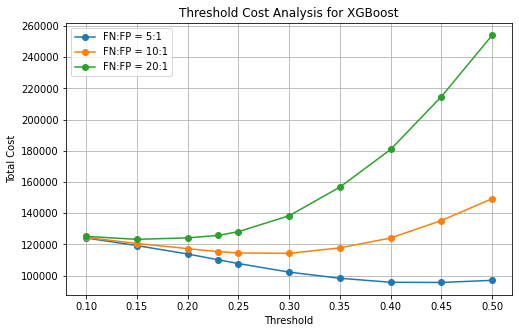

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    xgb_threshold_cost_df["Threshold"],
    xgb_threshold_cost_df["Cost_5_to_1"],
    marker="o",
    label="FN:FP = 5:1"
)

plt.plot(
    xgb_threshold_cost_df["Threshold"],
    xgb_threshold_cost_df["Cost_10_to_1"],
    marker="o",
    label="FN:FP = 10:1"
)

plt.plot(
    xgb_threshold_cost_df["Threshold"],
    xgb_threshold_cost_df["Cost_20_to_1"],
    marker="o",
    label="FN:FP = 20:1"
)

plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Threshold Cost Analysis for XGBoost")
plt.legend()
plt.grid(True)
plt.show()

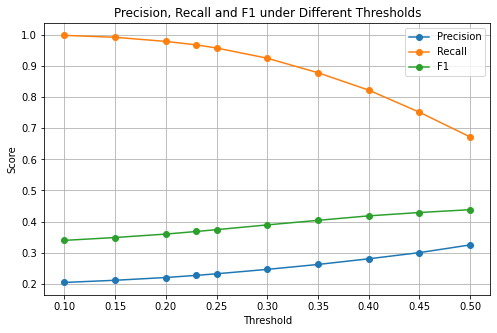

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    xgb_threshold_cost_df["Threshold"],
    xgb_threshold_cost_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    xgb_threshold_cost_df["Threshold"],
    xgb_threshold_cost_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    xgb_threshold_cost_df["Threshold"],
    xgb_threshold_cost_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 under Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
xgb_train_prob = best_xgb.predict_proba(x_train)[:, 1]
xgb_valid_prob = best_xgb.predict_proba(x_valid)[:, 1]
xgb_test_prob = best_xgb.predict_proba(x_test)[:, 1]

In [36]:
import numpy as np
import pandas as pd


def calculate_psi(expected, actual, buckets=10):
    """
    Calculate PSI between expected and actual distributions.
    
    expected: reference sample, usually train scores
    actual: comparison sample, usually valid/test scores
    buckets: number of bins
    """
    expected = np.array(expected)
    actual = np.array(actual)

    breakpoints = np.percentile(expected, np.arange(0, 100 + 100 / buckets, 100 / buckets))
    breakpoints = np.unique(breakpoints)

    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    expected_percents = expected_counts / len(expected)
    actual_percents = actual_counts / len(actual)

    # 避免 log(0)
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)

    psi_values = (actual_percents - expected_percents) * np.log(actual_percents / expected_percents)
    psi_total = np.sum(psi_values)

    psi_table = pd.DataFrame({
        "bin": range(1, len(expected_percents) + 1),
        "expected_percent": expected_percents,
        "actual_percent": actual_percents,
        "psi": psi_values
    })

    return psi_total, psi_table

In [37]:
psi_valid, psi_valid_table = calculate_psi(xgb_train_prob, xgb_valid_prob, buckets=10)
psi_test, psi_test_table = calculate_psi(xgb_train_prob, xgb_test_prob, buckets=10)

print("Train vs Validation Score PSI:", psi_valid)
print("Train vs Test Score PSI:", psi_test)

Train vs Validation Score PSI: 0.00010144000708560935
Train vs Test Score PSI: 6.409691181904039e-05


In [38]:
psi_summary = pd.DataFrame({
    "Comparison": ["Train vs Validation", "Train vs Test"],
    "Score PSI": [psi_valid, psi_test]
})

psi_summary

,Comparison,Score PSI
0,Train vs Validation,0.000101
1,Train vs Test,0.000064


In [39]:
# 核心特征分箱验证
import pandas as pd
import numpy as np

valid_analysis_df = x_valid.copy()
valid_analysis_df["y_true"] = np.array(y_valid)
valid_analysis_df["xgb_pred_prob"] = best_xgb_valid_prob

subgrade_validation = (
    valid_analysis_df
    .groupby("subGrade_coded")
    .agg(
        sample_count=("y_true", "count"),
        actual_default_rate=("y_true", "mean"),
        mean_predicted_prob=("xgb_pred_prob", "mean")
    )
    .reset_index()
    .sort_values("subGrade_coded")
)

subgrade_validation

,subGrade_coded,sample_count,actual_default_rate,mean_predicted_prob
0,1,5197,0.027708,0.115031
1,2,4451,0.044260,0.146132
2,3,4601,0.058900,0.175983
3,4,6126,0.071499,0.214581
4,5,7590,0.085639,0.260693
5,6,8340,0.105755,0.299908
6,7,8736,0.117560,0.321212
7,8,9753,0.129499,0.358468
8,9,9878,0.151346,0.390600
9,10,9885,0.162468,0.428359


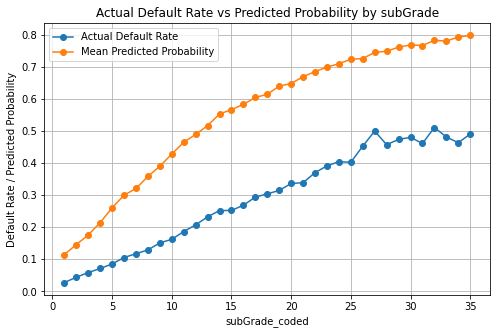

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    subgrade_validation["subGrade_coded"],
    subgrade_validation["actual_default_rate"],
    marker="o",
    label="Actual Default Rate"
)

plt.plot(
    subgrade_validation["subGrade_coded"],
    subgrade_validation["mean_predicted_prob"],
    marker="o",
    label="Mean Predicted Probability"
)

plt.xlabel("subGrade_coded")
plt.ylabel("Default Rate / Predicted Probability")
plt.title("Actual Default Rate vs Predicted Probability by subGrade")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
features_to_bin = ["interestRate", "dti_cleaned"]
def binning_validation(df, feature, y_col="y_true", pred_col="xgb_pred_prob", n_bins=10):
    temp = df[[feature, y_col, pred_col]].copy()
    
    temp[f"{feature}_bin"] = pd.qcut(
        temp[feature],
        q=n_bins,
        duplicates="drop"
    )
    
    result = (
        temp
        .groupby(f"{feature}_bin", observed=False)
        .agg(
            sample_count=(y_col, "count"),
            feature_min=(feature, "min"),
            feature_max=(feature, "max"),
            actual_default_rate=(y_col, "mean"),
            mean_predicted_prob=(pred_col, "mean")
        )
        .reset_index()
    )
    
    return result


interest_binning = binning_validation(valid_analysis_df, "interestRate", n_bins=10)
dti_binning = binning_validation(valid_analysis_df, "dti_cleaned", n_bins=10)

interest_binning

,interestRate_bin,sample_count,feature_min,feature_max,actual_default_rate,mean_predicted_prob
0,"(5.308999999999999, 7.39]",16124,5.31,7.39,0.048933,0.156478
1,"(7.39, 8.9]",16093,7.40,8.90,0.086994,0.258158
2,"(8.9, 10.49]",16281,8.94,10.49,0.125422,0.332996
3,"(10.49, 11.53]",16067,10.51,11.53,0.153358,0.401999
4,"(11.53, 12.74]",15576,11.55,12.74,0.167244,0.432926
5,"(12.74, 13.99]",19252,12.79,13.99,0.216653,0.492537
6,"(13.99, 15.28]",12608,14.03,15.28,0.227871,0.522143
7,"(15.28, 16.99]",16323,15.31,16.99,0.262207,0.573341
8,"(16.99, 19.52]",16122,17.04,19.52,0.312058,0.629913
9,"(19.52, 30.99]",15554,19.53,30.99,0.402919,0.706140


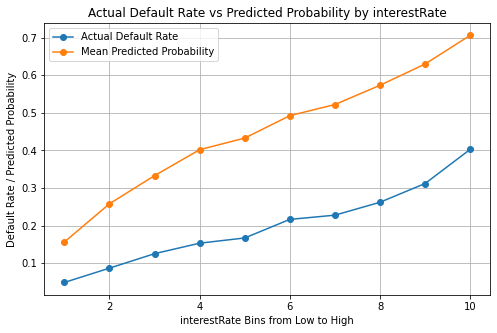

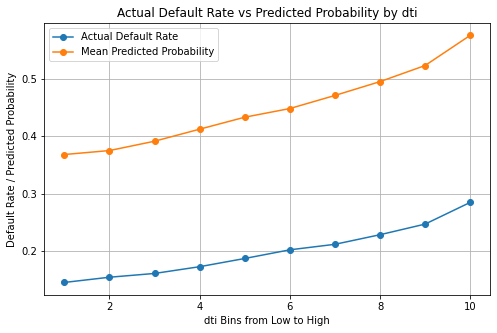

In [44]:
def plot_binning_validation(binning_df, feature_name):
    x = range(1, len(binning_df) + 1)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(
        x,
        binning_df["actual_default_rate"],
        marker="o",
        label="Actual Default Rate"
    )
    
    plt.plot(
        x,
        binning_df["mean_predicted_prob"],
        marker="o",
        label="Mean Predicted Probability"
    )
    
    plt.xlabel(f"{feature_name} Bins from Low to High")
    plt.ylabel("Default Rate / Predicted Probability")
    plt.title(f"Actual Default Rate vs Predicted Probability by {feature_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_binning_validation(interest_binning, "interestRate")
plot_binning_validation(dti_binning, "dti")